In [1]:
import bte


In [2]:
tree = bte.MATree("/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 102.6305 seconds


In [4]:
num_descendants = {}
for node in tree.depth_first_expansion(reverse=True):
    if node.is_leaf():
        num_descendants[node.id] = 1
    else:
        num_descendants[node.id] = sum(num_descendants[child.id]
                                       for child in node.children)

In [ ]:
# create a TextIO object to write to
import io
outputs = io.StringIO()

import re
from collections import Counter


def mut_to_class(s):
    # A123G becomes A>G
    return re.sub(r"(\w)(\d+)(\w)", r"\1>\3", s)


def mut_classes(muts):
    # Count the number of transitions and transversions
    muts = [mut_to_class(m) for m in muts]
    counts = Counter(muts)
    return counts


def get_transition_percentage(mut_classes):
    #transitions are G>A, A>G, C>T, T>C

    transitions = sum(mut_classes[k] for k in mut_classes
                      if k in ["G>A", "A>G", "C>T", "T>C"])
    total = sum(mut_classes.values())
    return transitions / total


year_counter = Counter()
mut_counter = Counter()

def year_from_id(node_id):
    components = node_id.split("|")
    if len(components) < 3:
        return None
    date = components[2]
    year = date.split("-")[0]
    if year in ["2019","2020", "2021", "2022", "2023", "2024", "2025","2026"]:
        return year
    else:
        return None


for node in tree.depth_first_expansion():
    if len(node.mutations) > 10:
        classes = mut_classes(node.mutations)
        class_props = {
            k: v / sum(classes.values())
            for k, v in classes.items()
        }
        transition_percentage = get_transition_percentage(classes)
        if class_props.get("G>A", 0) > 0.3 and class_props.get(
                "C>T", 0) > 0.25 and transition_percentage > 0.9:


            
            print(node.id, ",".join(node.mutations), {k:round(v,3) for k,v in class_props.items()}, transition_percentage, file = outputs)
            
            for mut in node.mutations:
                mut_counter[mut] += 1
            years = set()
            
            for descendant in tree.depth_first_expansion(nid=node.id):
                years.add(year_from_id(descendant.id))
                print("       ", descendant.id, file=outputs)
            if len(years) == 1:
                year_counter.update(years)

In [10]:
year_counter

Counter({'2022': 417,
         '2023': 312,
         '2024': 73,
         '2025': 12,
         '2021': 10,
         '2020': 2})

('2020', '2021', '2022', '2023', '2024', '2025')
(2, 10, 417, 312, 73, 12)


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_5451/3286482614.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_sorted, y=y_sorted, palette='rocket')


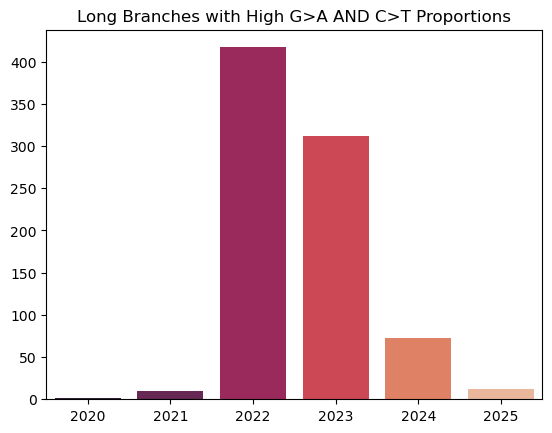

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
# title
plt.title("Long Branches with High G>A AND C>T Proportions")
# plot
x=list(year_counter.keys())
y=list(year_counter.values())
x_sorted, y_sorted = zip(*sorted(zip(x, y), key=lambda pair: int(pair[0])))
print(x_sorted)
print(y_sorted)
sns.barplot(x=x_sorted, y=y_sorted, palette='rocket')
# show
plt.show()

In [9]:
plt.savefig("/Users/reem/new_figs/GA_branches_by_year_UShER.svg", format='svg')

<Figure size 640x480 with 0 Axes>

In [9]:
print(outputs.getvalue())

USA/MN-MDH-3413/2021|EPI_ISL_1224847|2021-02-16 G805A,T1694C,G2081A,G4665A,T4699C,C7162T,G22226A,A24874G,G25062T,C28876T,C29400T,C29541T {'G>A': 0.333, 'T>C': 0.167, 'C>T': 0.333, 'A>G': 0.083, 'G>T': 0.083} 0.9166666666666666
        USA/MN-MDH-3413/2021|EPI_ISL_1224847|2021-02-16
Turkey/HSGM-9126/2021|EPI_ISL_1302782|2021-03-08 A759G,C884T,G1467A,C4002T,G4255A,G9572A,C10671T,C10755T,G12059A,C20703T,G21956A,C23731T,G24914C,T26621C {'A>G': 0.071, 'C>T': 0.429, 'G>A': 0.357, 'G>C': 0.071, 'T>C': 0.071} 0.9285714285714286
        Turkey/HSGM-9126/2021|EPI_ISL_1302782|2021-03-08
node_240679 C96T,G816A,C1420T,T1927C,G1940A,C2652T,C10029T,C14115T,C14790T,G23608A,C27389T,G28872A,C29171T {'C>T': 0.615, 'G>A': 0.308, 'T>C': 0.077} 1.0
        node_240679
        USA/MA-UMASSMED-P003C08/2020|EPI_ISL_3409802|2020-11-17
        USA/UMW22063234/2020|MW882592.1|2020-11-17
Philippines/PH-PGC-00060/2020|EPI_ISL_2154019|2020-11-16 C9996T,A10867G,T15252C,G19075A,T24259C,G24368C,G25052A,G25621A,C26305T,

In [10]:
#print(mut_to_class("A123C"))
muts = ["A123C", "G456T", "C789A", "T101G", "A111C", "G121A"]
mut_classes = mut_classes(muts)
print(mut_classes)
print(get_transition_percentage(mut_classes))

Counter({'A>C': 2, 'G>T': 1, 'C>A': 1, 'T>G': 1, 'G>A': 1})
0.16666666666666666


In [11]:
classes = {'A>C': 2, 'G>T': 1, 'C>A': 1, 'T>G': 1, 'G>A': 1}
class_props = {
            k: v / sum(classes.values())
            for k, v in classes.items()
        }
print(class_props)

{'A>C': 0.3333333333333333, 'G>T': 0.16666666666666666, 'C>A': 0.16666666666666666, 'T>G': 0.16666666666666666, 'G>A': 0.16666666666666666}


In [11]:
mut_counter.most_common()

[('C4230T', 19),
 ('C5178T', 19),
 ('G5180A', 17),
 ('G23282A', 15),
 ('C23809T', 15),
 ('C29370T', 15),
 ('G1886A', 15),
 ('C13197T', 15),
 ('C21588T', 14),
 ('G24770A', 13),
 ('G17242A', 13),
 ('C17738T', 12),
 ('G22580A', 12),
 ('C27519T', 12),
 ('C28791T', 12),
 ('G17749A', 12),
 ('G21956A', 11),
 ('G18340A', 11),
 ('G16485A', 11),
 ('C28849T', 11),
 ('C23664T', 11),
 ('G9092A', 11),
 ('C19547T', 11),
 ('G2585A', 11),
 ('C534T', 11),
 ('G24944A', 11),
 ('G13249A', 11),
 ('G22820A', 11),
 ('G2231A', 11),
 ('G24751A', 11),
 ('C12789T', 11),
 ('G12911A', 11),
 ('G15109A', 10),
 ('C21077T', 10),
 ('G11128A', 10),
 ('C24442T', 10),
 ('G28321A', 10),
 ('G26730A', 10),
 ('G22427A', 10),
 ('C16260T', 10),
 ('G15199A', 10),
 ('G10688A', 10),
 ('G3167A', 10),
 ('C26527T', 10),
 ('G27706A', 10),
 ('G24154A', 10),
 ('G6653A', 10),
 ('G11198A', 10),
 ('G28925A', 10),
 ('G1928A', 10),
 ('C9943T', 10),
 ('G9584A', 10),
 ('G24947A', 10),
 ('C10450T', 10),
 ('G6008A', 10),
 ('C19172T', 10),
 ('G155